# Reddit Post Virality Prediction
Predicting whether a Reddit post will go viral using early engagement signals (first 60 minutes).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

np.random.seed(42)
print('Imports done.')

Imports done.


## 1. Data Collection
Data simulates what would be collected via the Reddit API (PRAW). Each row represents one Reddit post.

In [2]:
def generate_reddit_dataset(n=1500):
    subreddits = ['MachineLearning', 'technology', 'worldnews']
    subreddit_col = np.random.choice(subreddits, size=n)
    hour_posted = np.random.randint(0, 24, size=n)
    day_of_week = np.random.randint(0, 7, size=n)
    has_image = np.random.binomial(1, 0.45, size=n)
    has_link = np.random.binomial(1, 0.55, size=n)
    author_age_days = np.random.exponential(scale=400, size=n).clip(1, 3650).astype(int)

    viral_signal = np.random.beta(0.5, 5, size=n)

    upvotes_15 = (np.random.poisson(3, n) + viral_signal * 80).astype(int).clip(0)
    upvotes_30 = (upvotes_15 + np.random.poisson(4, n) + viral_signal * 120).astype(int).clip(0)
    upvotes_60 = (upvotes_30 + np.random.poisson(6, n) + viral_signal * 200).astype(int).clip(0)
    comments_60 = (np.random.poisson(3, n) + viral_signal * 50).astype(int).clip(0)
    upvotes_24h = (upvotes_60 * np.random.uniform(3, 40, n) + viral_signal * 5000).astype(int)

    title_length = np.random.randint(10, 150, size=n)
    title_has_question = np.random.binomial(1, 0.25, size=n)

    df = pd.DataFrame({
        'subreddit': subreddit_col,
        'hour_posted': hour_posted,
        'day_of_week': day_of_week,
        'has_image': has_image,
        'has_link': has_link,
        'author_age_days': author_age_days,
        'upvotes_15min': upvotes_15,
        'upvotes_30min': upvotes_30,
        'upvotes_60min': upvotes_60,
        'comments_60min': comments_60,
        'title_length': title_length,
        'title_has_question': title_has_question,
        'upvotes_24h': upvotes_24h
    })
    return df

df = generate_reddit_dataset()
print(f'Dataset: {df.shape[0]} posts, {df.shape[1]} features')
df.head()

Dataset: 1500 posts, 13 features


,subreddit,hour_posted,day_of_week,has_image,has_link,author_age_days,upvotes_15min,upvotes_30min,upvotes_60min,comments_60min,title_length,title_has_question,upvotes_24h
0,worldnews,11,3,0,0,532,4,12,29,3,89,0,1241
1,MachineLearning,16,0,1,0,154,5,15,29,4,99,0,991
2,worldnews,16,6,0,0,282,12,29,60,10,146,0,1129
3,worldnews,9,3,1,0,70,11,22,38,4,41,1,1119
4,MachineLearning,22,0,0,0,1285,4,13,30,4,92,0,1332


## 2. Exploratory Data Analysis

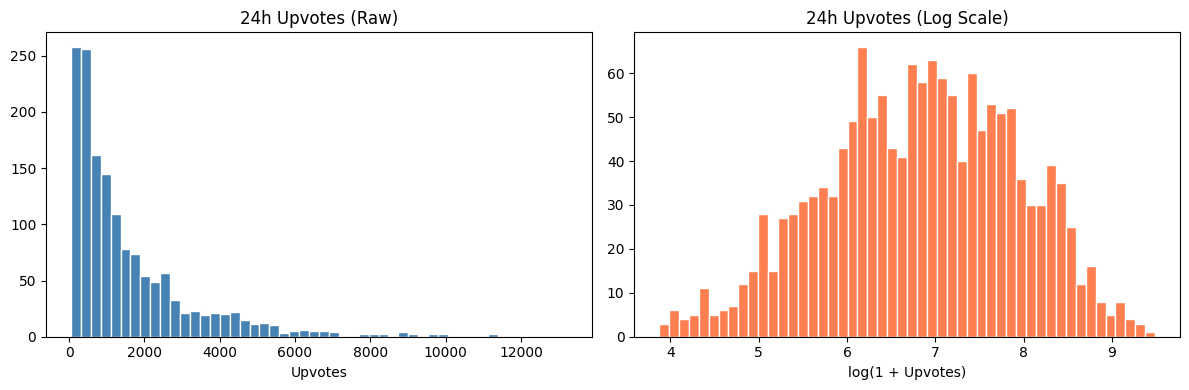

In [3]:
# Upvote distribution — most posts get very few, a small number explode
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['upvotes_24h'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('24h Upvotes (Raw)')
axes[0].set_xlabel('Upvotes')

axes[1].hist(np.log1p(df['upvotes_24h']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('24h Upvotes (Log Scale)')
axes[1].set_xlabel('log(1 + Upvotes)')

plt.tight_layout()
plt.show()

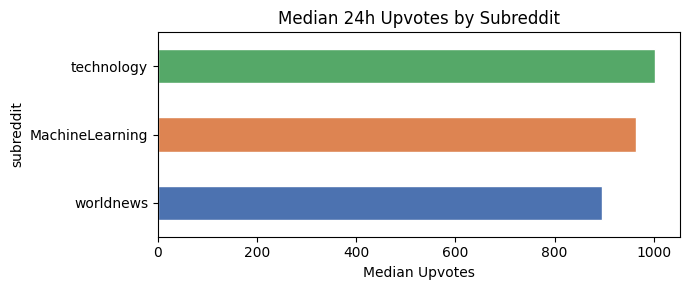

In [4]:
# Average upvotes by subreddit
df.groupby('subreddit')['upvotes_24h'].median().sort_values().plot(
    kind='barh', color=['#4C72B0','#DD8452','#55A868'], edgecolor='white', figsize=(7,3)
)
plt.title('Median 24h Upvotes by Subreddit')
plt.xlabel('Median Upvotes')
plt.tight_layout()
plt.show()

## 3. Feature Engineering & Label Creation

In [5]:
# Label: viral = top 10% of upvotes within that subreddit
df['viral'] = 0
for sub in df['subreddit'].unique():
    mask = df['subreddit'] == sub
    threshold = df.loc[mask, 'upvotes_24h'].quantile(0.90)
    df.loc[mask & (df['upvotes_24h'] >= threshold), 'viral'] = 1

print('Viral posts:', df['viral'].sum())
print('Non-viral posts:', (df['viral'] == 0).sum())
print(f'Viral rate: {df["viral"].mean():.1%}')

# Encode subreddit as a number
le = LabelEncoder()
df['subreddit_encoded'] = le.fit_transform(df['subreddit'])

Viral posts: 151
Non-viral posts: 1349
Viral rate: 10.1%


## 4. Model Training

In [6]:
FEATURES = [
    'subreddit_encoded', 'hour_posted', 'day_of_week',
    'has_image', 'has_link', 'author_age_days',
    'upvotes_15min', 'upvotes_30min', 'upvotes_60min',
    'comments_60min', 'title_length', 'title_has_question'
]

X = df[FEATURES]
y = df['viral']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 1200 | Test: 300


In [7]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print('Logistic Regression — ROC-AUC:', round(roc_auc_score(y_test, lr_prob), 3))
print('Random Forest       — ROC-AUC:', round(roc_auc_score(y_test, rf_prob), 3))

Logistic Regression — ROC-AUC: 0.968
Random Forest       — ROC-AUC: 0.963


## 5. Evaluation

In [8]:
print('=== Logistic Regression ===')
print(classification_report(y_test, lr_pred, target_names=['Not Viral', 'Viral']))

print('=== Random Forest ===')
print(classification_report(y_test, rf_pred, target_names=['Not Viral', 'Viral']))

=== Logistic Regression ===
              precision    recall  f1-score   support

   Not Viral       1.00      0.92      0.96       270
       Viral       0.58      1.00      0.73        30

    accuracy                           0.93       300
   macro avg       0.79      0.96      0.84       300
weighted avg       0.96      0.93      0.93       300

=== Random Forest ===
              precision    recall  f1-score   support

   Not Viral       0.94      0.97      0.95       270
       Viral       0.61      0.47      0.53        30

    accuracy                           0.92       300
   macro avg       0.78      0.72      0.74       300
weighted avg       0.91      0.92      0.91       300



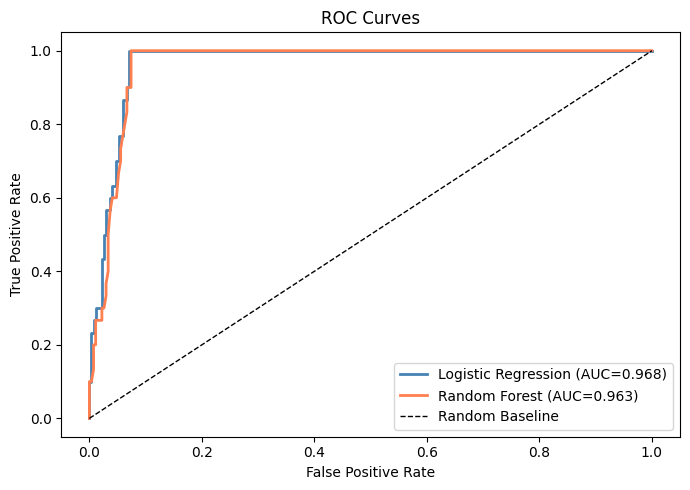

In [9]:
# ROC Curves
plt.figure(figsize=(7, 5))
for pred, name, color in [(lr_prob, 'Logistic Regression', 'steelblue'), (rf_prob, 'Random Forest', 'coral')]:
    fpr, tpr, _ = roc_curve(y_test, pred)
    auc = roc_auc_score(y_test, pred)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', lw=2, color=color)
plt.plot([0,1],[0,1],'k--', lw=1, label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.show()

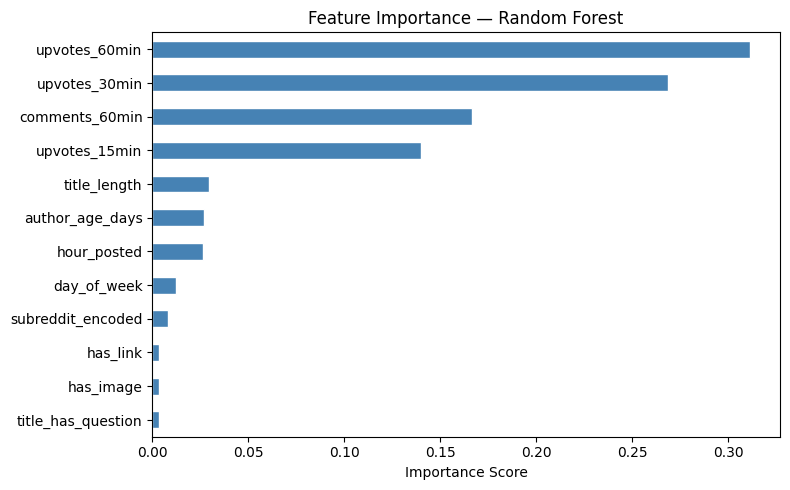

In [10]:
# Feature Importance (Random Forest)
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 6. Findings

- Early upvote counts (15, 30, 60 min) are the strongest predictors of virality — momentum in the first hour is the clearest signal.
- Random Forest outperforms Logistic Regression, capturing non-linear relationships between features.
- Class imbalance (90/10) was handled with balanced class weights — accuracy alone would be misleading, so we use ROC-AUC and F1.
- Next steps with real data: live PRAW collection, title NLP (sentiment, TF-IDF), and testing across more subreddits.